<a href="https://colab.research.google.com/github/Adeleyi/translation-analysis/blob/ngram-analysis/SSA_COMET_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluating SSA-COMET-MTL: English ↔ Yorùbá MT Quality**

**SSA-COMET-MTL** is a translation quality metric for evaluating machine translation (MT) outputs. It scores how good a translation is—with or without a reference—based on human ratings.The model is built on AfroXLMR‑76L and supports 76 African  languages, including **Yorùbá**.

In this notebook, we test the model on translations in both directions:  
**Yorùbá → English** and **English → Yorùbá**, at both **sentence level** and **document (paragraph) level**, with and without reference translations.

All MT outputs used here were generated by **ChatGPT**.

### **Setup**

To get started, we install the `unbabel-comet` package and load the SSA-COMET-MTL model from Hugging Face. The code below downloads the model checkpoint and loads it so it’s ready for scoring translations.


In [43]:
!pip install -q unbabel-comet


In [44]:
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

In [45]:
# Import necessary libraries
import json
import pandas as pd
import matplotlib.pyplot as plt

# Download and load the SSA-COMET-MTL model
from comet import download_model, load_from_checkpoint
model_path = download_model("McGill-NLP/ssa-comet-mtl")
model = load_from_checkpoint(model_path)



Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

### **Sentence-Level Evaluation**




In [46]:
sent_level = [
    # Sentence-level examples with reference text (Yorùbá → English)
     { # 1
        "src": "Ó kéré tán, nǹkan bí ẹgbẹ̀rún kan àti ọgọ́rùn ún mẹ́fà lára àwọn ọmọ tí wọ́n rán jáde ló ti pàdánù ọjà kan.",
        "mt": "At the very least, about one thousand six hundred of the children who were sent out have gone missing in a single market.",
        "ref": "At least, about one thousand and six hundred out of the children that were sent out has lost one goods."
    },
    { # 2
       "src": "Mo rọ gbogbo ọmọ Nàìjíríà pé kí wọ́n má mìkàn tí a ó fi ṣẹ́gun àrùn kòró.",
       "mt": "I urge all Nigerians not to relent in our efforts to overcome the coronavirus.",
       "ref": "I urge all Nigerians not to lose hope until we defeat the disease."
    },

    # Without reference text (Yorùbá → English)
    { # 3
        "src": "Ohun èlò kan wà tí wọ́n hùn bí apẹ̀rẹ̀ tí wọ́n ma ń ko adìyẹ àti òròmadìye si. Kí ni orúkọ rẹ̀?",
        "mt": "There is an object woven like a basket that is used to carry chickens and chicks. What is it called?"
    },
    { # 4
        "src": "Inú obìnrin yìí sì dùn gan an báyìí, ó ń mú àwọn ohun èlò rẹ̀ wá sí ọjà",
        "mt": "This woman is very happy now; she’s bringing her wares to the market."
    },
    { # 5
        "src": "Ó kéré tán, nǹkan bí ẹgbẹ̀rún kan àti ọgọ́rùn ún mẹ́fà lára àwọn ọmọ tí wọ́n rán jáde ló ti pàdánù ọjà kan.",
        "mt": "At the very least, about one thousand six hundred of the children who were sent out have gone missing in a single market."
    },

# English → Yoruba
    { # 6
        "src": "I forgot to charge my phone again last night.",
        "mt": "Mo gbagbe lati fi foonu mi síná lẹ́ẹkansi lálẹ́ yìí."
    },
    { # 7
        "src": "After finishing her morning chores, she sat on the front porch with a cup of tea, watching people pass by and thinking about everything she still had to do before the day ended",
        "mt": "Lẹ́yìn tí ó parí gbogbo iṣẹ́ owurọ̀ rẹ, ó jókòó lórí pẹpẹ ilé pẹ̀lú ife tii, ó ń wo àwọn ènìyàn tí ń kọjá lọ, ó sì ń ròyìn gbogbo ohun tí ó ṣi kù kí ó tó parí ọjọ́ náà."
    },
    { # 8
        "src": "Italy's national football, along with German national football team is the second most successful team in the world and were the FIFA World Cup champions in 2006.",
        "mt": "Ẹgbẹ́ bọ́ọ̀lù orílẹ̀-èdè Italy, pẹ̀lú ẹgbẹ́ bọ́ọ̀lù orílẹ̀-èdè Germany, ni ẹgbẹ́ kejì tó ṣàṣeyọrí jùlọ ní ayé, wọ́n sì ṣẹ́gun Aṣàájú Àgbáyé FIFA ní ọdún 2006.",
        "ref": "Egbe agbaboolu ilu Itili pelu ti Jamani ni egbe agbaboolu keji to se aseyori ju laye, awon de lo gbe igba oroke ni Ere Idije FIFA Koopu Agbaye ni 2006."
    },
    {
        "src": "Italy's national football, along with German national football team is the second most successful team in the world and were the FIFA World Cup champions in 2006.",
        "mt": "Ẹgbẹ́ bọ́ọ̀lù orílẹ̀-èdè Italy, pẹ̀lú ẹgbẹ́ bọ́ọ̀lù orílẹ̀-èdè Germany, ni ẹgbẹ́ kejì tó ṣàṣeyọrí jùlọ ní ayé, wọ́n sì ṣẹ́gun Aṣàájú Àgbáyé FIFA ní ọdún 2006."
    }

]

In [47]:
model_output = model.predict(sent_level, batch_size=8, gpus=1)

for sent, score in enumerate(model_output["scores"]):
    print(f"Example {sent+1}:")
    print(f"  Score: {score:.4f}\n")

Predicting DataLoader 0: 100%|██████████| 2/2 [00:20<00:00, 10.12s/it]


Example 1:
  Score: 0.4701

Example 2:
  Score: 0.6631

Example 3:
  Score: 0.5330

Example 4:
  Score: 0.5229

Example 5:
  Score: 0.4701

Example 6:
  Score: 0.7061

Example 7:
  Score: 0.7365

Example 8:
  Score: 0.6753

Example 9:
  Score: 0.6753



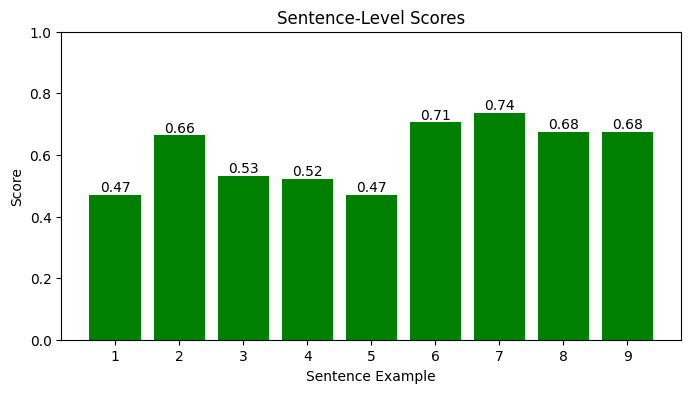

In [48]:

sent_scores = model_output["scores"]

plt.figure(figsize=(8, 4))
bars = plt.bar(range(1, len(sent_scores)+1), sent_scores, color="green")
plt.xticks(range(1, len(sent_scores)+1))
plt.xlabel("Sentence Example")
plt.ylabel("Score")
plt.title("Sentence-Level Scores")
plt.ylim(0, 1)

for i in range(len(sent_scores)):
    plt.text(i + 1, sent_scores[i] + 0.01, f"{sent_scores[i]:.2f}", ha='center')

plt.show()


####  **Sentence-Level Observations**

- The **highest scores** came from *English → Yorùbá* translations (Examples 6 & 7), suggesting the model performs better in this direction at sentence level.

- **Example 1**, with a reference, scored low. I reran the same source and MT in **Example 5** without a reference -no change. Same outcome with **Examples 8 & 9**. This suggests the model prioritizes semantic alignment with the source over reference similarity. The source text clearly plays a central role, with the MT judged primarily on how well it reflects the source meaning.

- **Examples 3 & 4** (Yorùbá → English, no reference) were strong by human judgment, but only scored slightly above average. The model may be less confident with Yorùbá as the source.

### **Document-Level Evaluation**

In [49]:
df = pd.read_csv("/content/drive/MyDrive/The African Research Collective/doc-level.csv")

df.head(10)

,src,mt,ref
0,Ọlọrun ni agbara lati ṣe ohun gbogbo. Bi O ba ...,God has the power to do all things. As He has ...,NaN
1,"Ọlọrun si ri ohun gbogbo ti O dá, si kiyesi i,...","And God saw everything that He had made, and b...",NaN
2,Njẹ o le ṣe afiwe iye iṣoogun ti mimu siga ati...,Can you compare the medicinal value of smoking...,NaN
3,"Welcome to Hogwarts,” said Professor McGonagal...","Ẹ káàbọ̀ sí Hogwarts,” ni Professor McGonagall...",NaN
4,The morning sun rose slowly over the rooftops ...,Ìmọ̀lẹ̀ òwúrọ̀ bẹ̀rẹ̀ sí í tàn lórí orílé-oríl...,NaN
5,Paychant – Powering Africa's Fiat-to-Crypto Ga...,Paychant- Ó ń fi agbára fún Áfíríkà láti ṣàlày...,NaN
6,"Kenyan agritech startup, FarmWorks, raises a $...",Ilé-iṣẹ́ àdìdeelẹ̀ iṣẹ́ àgbẹ̀ onímọ̀ ẹ̀rọ ilẹ̀...,NaN
7,Ethiopia fi òpin sí ìfòfin de ìkànnì ìbánidọ́r...,Ethiopia ends a 5-month social media ban The C...,NaN
8,A partnership agreement is preventing LagosRid...,Àdéhùn ìbánidókòwò ń dènà àwọn awakọ̀ nílùú Èk...,NaN
9,Twiga Foods ṣe àdínkù iye òṣìṣẹ́ Ǹjẹ́ o ti jẹ́...,Twiga Foods reduces its headcount Have you eve...,NaN


In [50]:
doc_level = [{"src": src, "mt": mt} for src, mt in zip(df["src"], df["mt"])]

model_output_doc = model.predict(doc_level, batch_size=4, gpus=0)
for i, score in enumerate(model_output_doc["scores"]):
    print(f"Doc {i+1}: {score:.4f}")


Predicting DataLoader 0: 100%|██████████| 3/3 [01:01<00:00, 20.45s/it]

Doc 1: 0.4497
Doc 2: 0.3399
Doc 3: 0.4838
Doc 4: 0.4204
Doc 5: 0.3103
Doc 6: 0.2911
Doc 7: 0.3689
Doc 8: 0.2315
Doc 9: 0.3229
Doc 10: 0.1859


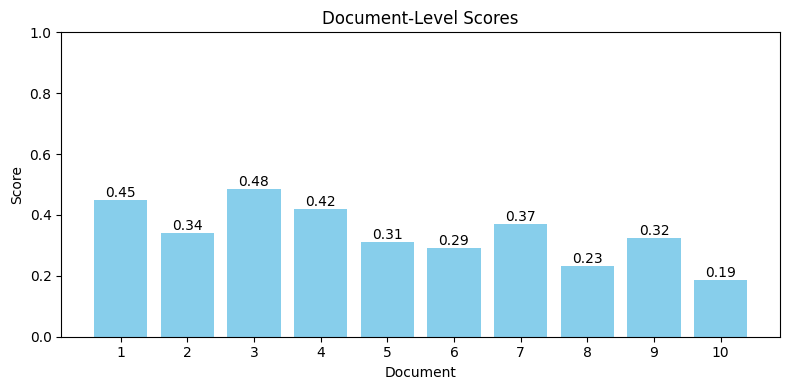

In [51]:
scores = model_output_doc["scores"]

plt.figure(figsize=(8, 4))
bars = plt.bar(range(1, len(scores)+1), scores, color="skyblue")
plt.xticks(range(1, len(scores)+1))
plt.xlabel("Document")
plt.ylabel("Score")
plt.title("Document-Level Scores")
plt.ylim(0, 1)

for i in range(len(scores)):
    plt.text(i + 1, scores[i] + 0.01, f"{scores[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()


#### Doc_Level Observations
- The model clearly struggled with longer texts. Processing was slower, and none of the scores passed 0.5. Some dropped as low as **0.18**.

- **English → Yorùbá**, which performed well at sentence level, had surprisingly low scores here.  


###  Key Findings

- **Best direction**: English → Yorùbá, especially at sentence level. Higher, more consistent scores.
- **Yorùbá → English**: Lower scores, model seems cautious here.

- **Sentence-level**: More reliable, faster.
- **Paragraph-level**: Lower scores, slower, less consistent. Model struggles with longer, descriptive inputs.

- **Reference**: Often had little impact. Model mainly relies on MT-source alignment.